In [3]:
import pandas as pd
import import_ipynb
import nbimporter
from utils import prepareTrainingSet3Sec,prepareTrainingSet30Sec,standardization,Grafico_Before_After,Grafico_Tre_Valori, ConfrontoGrafico_30_e_3, evaluate_Model,metrics# type: ignore
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV  
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score
from sklearn.exceptions import ConvergenceWarning
import warnings


SENZA STANDARDIZZAZIONE

In [61]:
#preparazione del training set
X_train, X_test, y_train, y_test= prepareTrainingSet30Sec()

# Disabilitare i messaggi di warning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Creare il modello Logistic
model = LogisticRegression(max_iter=300, solver='lbfgs', penalty='l2', C=0.1, multi_class='ovr', random_state=42)
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test

y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

#controllo overfitting
evaluate_Model(y_test, y_pred,y_train, y_pred_train)


c:\Users\romeo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


---------STATISTICHE TEST----------
Accuratezza: 0.5500
Precision: 0.5771
Recall: 0.5611
F1-score: 0.5534
F2-score: 0.5550
---------STATISTICHE TRAING----------
Accuratezza: 0.5988
Precision: 0.5925
Recall: 0.5949
F1-score: 0.5874
F2-score: 0.5904

=== Analisi ===
Il modello potrebbe soffrire di UNDERFITTING (performance bassa su entrambi i set).


con standardizzazione

In [75]:
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
model = LogisticRegression(max_iter=1000, solver='sag', penalty='l2', C=0.6, multi_class='ovr', random_state=42)
X_train, X_test= standardization(X_train, X_test)
model.fit(X_train, y_train)
            # Valutazione del modello
y_pred = model.predict(X_test)


y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

#controllo overfitting
evaluate_Model(y_test, y_pred,y_train, y_pred_train)



c:\Users\romeo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


---------STATISTICHE TEST----------
Accuratezza: 0.7100
Precision: 0.7213
Recall: 0.7283
F1-score: 0.7223
F2-score: 0.7253
---------STATISTICHE TRAING----------
Accuratezza: 0.8612
Precision: 0.8591
Recall: 0.8597
F1-score: 0.8583
F2-score: 0.8589

=== Analisi ===
Il modello potrebbe soffrire di OVERFITTING (performance molto migliore sul training set).


grid search

In [12]:
# Definire i parametri per la Grid Search
param_grid = {
    'solver': ['saga', 'lbfgs', 'newton-cg'],
    'max_iter': [1000, 2000, 5000],
    'C': [ 0.01, 0.1, 1,]
}

# Creare il modello Logistic
model = LogisticRegression()

# Creare il GridSearchCV
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')

# Eseguire la Grid Search
grid_search.fit(X_train, y_train)

# Miglior modello trovato dalla Grid Search
best_model = grid_search.best_estimator_

# Prevedere le etichette per il set di test
y_pred = best_model.predict(X_test)

# Calcolo e stampa delle metriche
accuracy = accuracy_score(y_test, y_pred)
print("Best parameters found: ", grid_search.best_params_)





Best parameters found:  {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}


con grid e standardizzazione

In [14]:
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
model = LogisticRegression(max_iter=1000, C=  1,  solver= 'lbfgs')
X_train, X_test= standardization(X_train, X_test)
model.fit(X_train, y_train)
            # Valutazione del modello
y_pred = model.predict(X_test)
metrics(y_test, y_pred)
after_30sec=accuracy_score(y_test, y_pred)
logisticRegression30Sec= after_30sec

Accuratezza: 0.7100
Precision: 0.7263
Recall: 0.7291
F1-score: 0.7229


FACCIO IL LASSO

In [14]:
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.preprocessing import LabelEncoder

# Standardizzare i dati
X_train, X_test = standardization(X_train, X_test)

# Encode the labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Creare il modello Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train_encoded)

# Selezionare le feature non nulle
selected_features = np.where(lasso.coef_ != 0)[0]
X_train_selected = X_train[:, selected_features]
X_test_selected = X_test[:, selected_features]

# Addestrare il modello Logistic Regression sulle feature selezionate
model = LogisticRegression(max_iter=1000, C=1, solver='lbfgs')
model.fit(X_train_selected, y_train_encoded)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test_selected)
y_pred_train = model.predict(X_train_selected)

# Decode the predictions
y_pred = label_encoder.inverse_transform(y_pred)
y_pred_train = label_encoder.inverse_transform(y_pred_train)

# Valutare il modello
evaluate_Model(y_test, y_pred, y_train, y_pred_train)

---------STATISTICHE TEST----------
Accuratezza: 0.4200
Precision: 0.3927
Recall: 0.4552
F1-score: 0.4121
F2-score: 0.4351
---------STATISTICHE TRAING----------
Accuratezza: 0.4612
Precision: 0.4273
Recall: 0.4536
F1-score: 0.4313
F2-score: 0.4430

=== Analisi ===
Il modello potrebbe soffrire di OVERFITTING (performance molto migliore sul training set).


In [16]:
from sklearn.model_selection import cross_val_score

# Creare il modello Logistic
model = LogisticRegression(max_iter=1000, C=1, solver='lbfgs')

# Eseguire la cross-validation
scores = cross_val_score(model, X_train_selected, y_train_encoded, cv=5, scoring='accuracy')

# Stampa dei risultati
print(f"Accuratezza per ogni fold: {scores}")
print(f"Accuratezza media: {scores.mean():.4f}")
print(f"Deviazione standard: {scores.std():.4f}")

Accuratezza per ogni fold: [0.43125 0.44375 0.475   0.4375  0.48125]
Accuratezza media: 0.4538
Deviazione standard: 0.0204


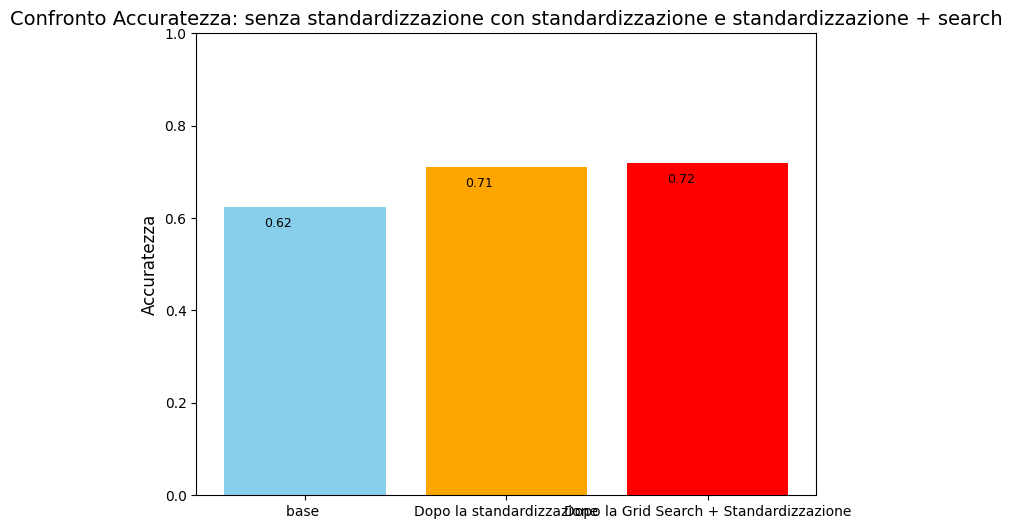

In [8]:
Grafico_Tre_Valori(before_30sec,before_30sec_standadization,after_30sec)

con 3 secondi

In [1]:

X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
# Creare il modello Logistic
model = LogisticRegression(max_iter=1000, solver='newton-cg')
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test)

# Calcolo e stampa delle metriche
metrics(y_test, y_pred)
before_3sec=accuracy_score(y_test, y_pred)

NameError: name 'prepareTrainingSet3Sec' is not defined

In [10]:
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
X_train, X_test= standardization(X_train, X_test)

model=LogisticRegression(max_iter=1000, solver='newton-cg')

model.fit(X_train, y_train)
            # Valutazione del modello
y_pred = model.predict(X_test)
metrics(y_test, y_pred)
before_3sec_standadization=accuracy_score(y_test, y_pred)

Accuratezza: 0.7362
Precision: 0.7317
Recall: 0.7371
F1-score: 0.7330


In [ ]:
 #Definizione del pipeline con standardizzazione e Logistic Regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardizzazione delle features
    ('classifier', LogisticRegression(max_iter=1000))  # Classificatore Logistic Regression
])

# Definizione degli iperparametri da testare con GridSearch, con combinazioni compatibili
param_grid = [
    {'classifier__C': [0.01, 0.1, 1], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs']},
    {'classifier__C': [0.01, 0.1, 1], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']},
    {'classifier__C': [0.01, 0.1, 1], 'classifier__penalty': ['l1', 'l2', 'elasticnet'], 
     'classifier__solver': ['saga'], 'classifier__l1_ratio': [0.5]}  # l1_ratio solo per elasticnet con saga
]

# Inizializzazione della GridSearchCV con validazione incrociata a 5 fold
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Esecuzione della ricerca
grid_search.fit(X_train, y_train)

# Migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)


In [ ]:
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
model = LogisticRegression(max_iter=1000, C=  1, l1_ratio=0.5, penalty= 'elasticnet', solver= 'saga')
X_train, X_test= standardization(X_train, X_test)
model.fit(X_train, y_train)
            # Valutazione del modello
y_pred = model.predict(X_test)
metrics(y_test, y_pred)
after_3sec=accuracy_score(y_test, y_pred)
logisticRegression3Sec= after_3sec

Accuratezza: 0.7372
Precision: 0.7325
Recall: 0.7380
F1-score: 0.7338
F2-score: 0.7360


c:\Users\romeo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


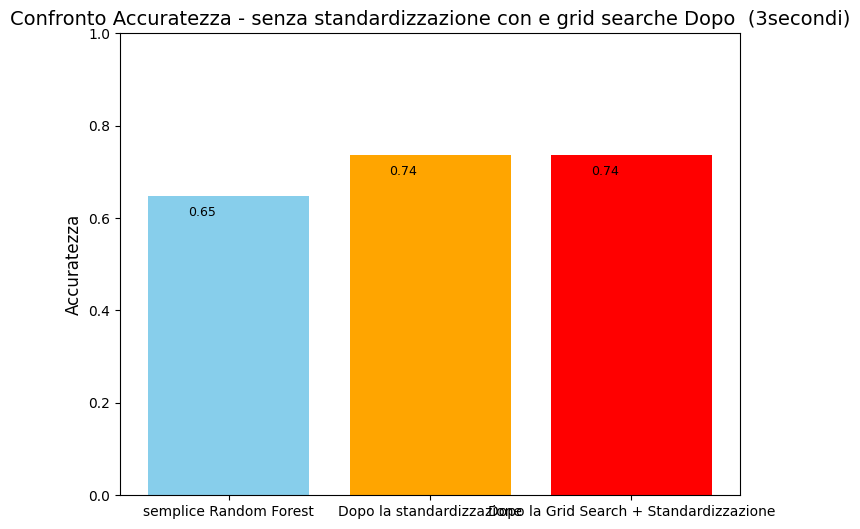

In [ ]:
Grafico_Tre_Valori(before_3sec,before_3sec_standadization,after_3sec)


Accuratezza per ogni fold: [0.6986986986986987, 0.7097097097097097, 0.6986986986986987, 0.7137137137137137, 0.7337337337337337, 0.7467467467467468, 0.7157157157157157, 0.7357357357357357, 0.7027027027027027, 0.7247247247247247]
Accuratezza media dopo K-Fold: 0.7180
Numero Feature selezionate: 50

Feature selezionate dal Lasso: ['chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'perceptr_mean', 'perceptr_var', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_va

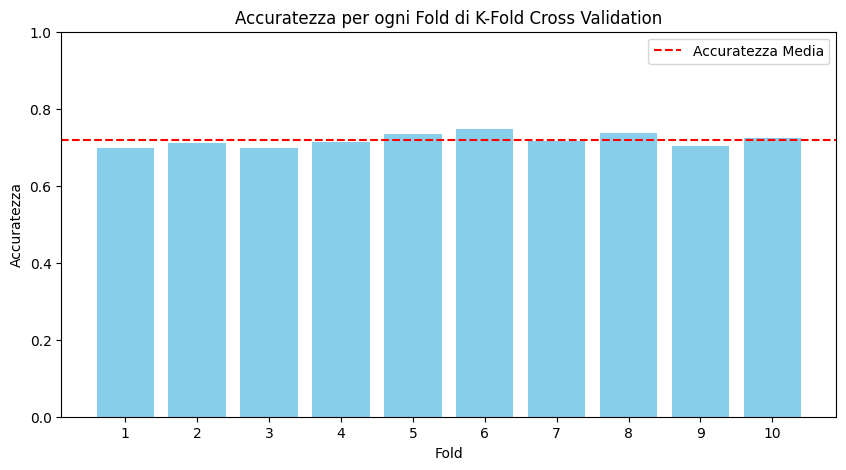

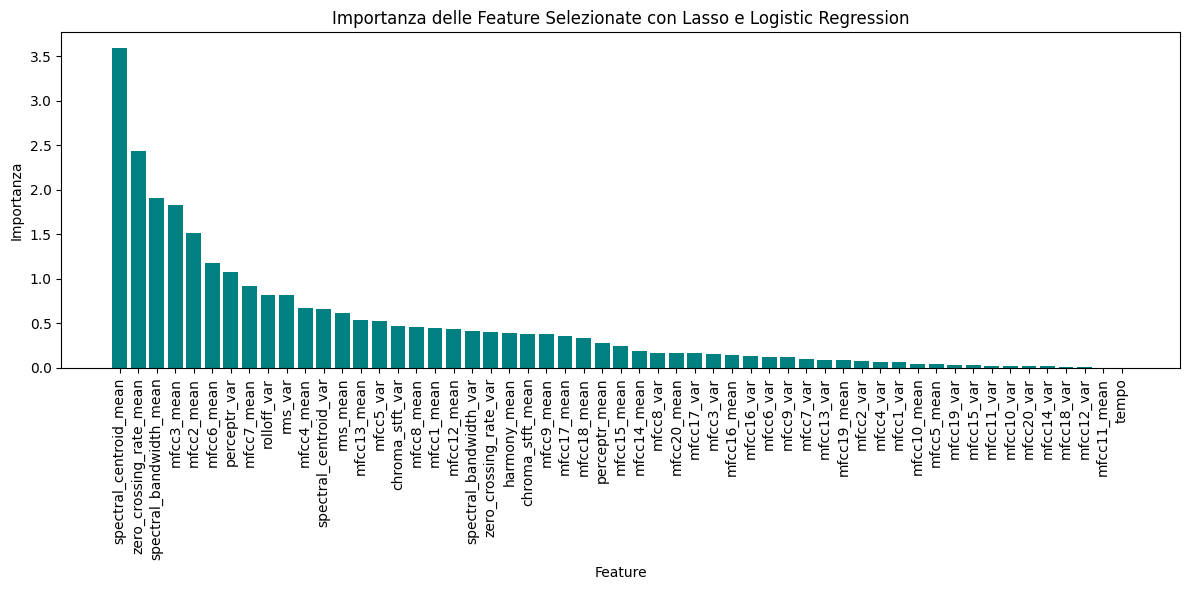

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Carica i dati dal CSV
file_path = 'Data/features_3_sec.csv'
data = pd.read_csv(file_path)

# Separare le caratteristiche e le etichette
X = data.drop(columns=['filename', 'label'])
y = data['label']

# Converti le etichette in valori numerici
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Standardizza le caratteristiche
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inizializza la cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Variabili per la valutazione
accuracies = []
importances_dict = {}  # Dizionario per tracciare le importanze delle feature selezionate

# Loop attraverso ogni fold
for train_index, test_index in kf.split(X_scaled, y_encoded):
    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Selezione delle feature con Lasso
    lasso = Lasso(alpha=0.01)
    lasso.fit(X_train, y_train)

    # Seleziona le feature non nulle
    selected_features = np.where(lasso.coef_ != 0)[0]
    X_train_selected = X_train[:, selected_features]
    X_test_selected = X_test[:, selected_features]

    # Addestra il modello Logistic Regression sulle feature selezionate
    model = LogisticRegression(max_iter=10000, C=  1, l1_ratio=0.5, penalty= 'elasticnet', solver= 'saga')
    model.fit(X_train_selected, y_train)

    # Calcolare l'importanza delle feature (usiamo i coefficienti della Logistic Regression)
    importances = np.abs(model.coef_[0])  # Prendiamo il valore assoluto dei coefficienti
    
    # Salvare le importanze con il nome della feature
    for i, feature_index in enumerate(selected_features):
        feature_name = X.columns[feature_index]
        if feature_name in importances_dict:
            importances_dict[feature_name].append(importances[i])
        else:
            importances_dict[feature_name] = [importances[i]]

    # Valuta il modello
    y_pred = model.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# Risultati finali
print(f"Accuratezza per ogni fold: {accuracies}")
print(f"Accuratezza media dopo K-Fold: {np.mean(accuracies):.4f}")
print(f"Numero Feature selezionate: {len(selected_features)}")
selected_feature_names = X.columns[selected_features].tolist()
print("\nFeature selezionate dal Lasso:", selected_feature_names)
print(f"Feature selezionate: {(selected_features)}")

# Calcolare la media delle importanze delle feature selezionate
mean_importances = {feature: np.mean(importance_list) for feature, importance_list in importances_dict.items()}

# Ordina le feature in base alla loro importanza media
sorted_features = sorted(mean_importances, key=mean_importances.get, reverse=True)
sorted_importances = [mean_importances[feature] for feature in sorted_features]

# Grafico delle accuratezze
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(accuracies) + 1), accuracies, color='skyblue')
plt.xlabel('Fold')
plt.ylabel('Accuratezza')
plt.title('Accuratezza per ogni Fold di K-Fold Cross Validation')
plt.ylim(0, 1)
plt.xticks(range(1, len(accuracies) + 1))
plt.axhline(y=np.mean(accuracies), color='r', linestyle='--', label='Accuratezza Media')
plt.legend()
plt.show()

# Grafico dell'importanza delle feature (con assi scambiati)
plt.figure(figsize=(12, 6))
plt.bar(sorted_features, sorted_importances, color='teal')
plt.ylabel('Importanza')
plt.xlabel('Feature')
plt.title('Importanza delle Feature Selezionate con Lasso e Logistic Regression')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
ConfrontoGrafico_30_e_3(before_3sec_standadization,before_30sec_standadization,after_3sec,after_30sec)